# Signály a systémy - projekt 2022/23

Autor řešení: David Kvaček, xkvace00
Datum řešení: 18.12.2022

### 1. Základy

Celý projekt jsem zpracovával v Python notebooku. Proto jsem nejprve importoval všechny potřebné moduly. Následně jsem načetl soubor se všemi tóny do odpovídajících proměnných, se kterými jsem nadále mohl pracovat. Zavedl jsem také několik magických konstant pro přístup k různým hodnotám, které jsem poté mohl využívat. Pomocí zadané MIDI frekvence jsem si spočítal periody pro jednotlivé zadané tři tóny.

Pro každý ze tří zadaných tónů jsem si určil začátek a konec signálu v ustálené části pro tři periody, kterou jsem poté zobrazil v grafu. Nad 0.5 s dlouhým úsekem daného tónu jsem provedl diskrétní Fourierovu transformaci (DFT), upravil jsem rozsahy os a zobrazil jsem spektrum každého ze trří tónů jako logaritmus druhé mocniny absolutních hodnot DFT.

Nakonec jsem všechny tři tóny v ustálené části (0.5 s) uložil do jednotlivých souborů.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa as lb

# Nacteni zvukoveho souboru pomoci knihovny soundfile a jeji funkce read().
# Zvukova stopa je ulozena do pole s a vzorkovaci frekvence do promenne Fs.
# Zavedeni magickych konstant do odpovidajicich promennych.
s, Fs = sf.read('klavir.wav')

MIDI_FROM = 24
MIDI_TO = 108
SKIP_SEC = 0.25
HOW_MUCH_SEC = 0.5
WHOLE_TONE_SEC = 2
TONE_SAMPLES = 2 * Fs

FIRST_TONE = 28
SECOND_TONE = 53
THIRD_TONE = 95

INTERVAL = 50
STEP = 200

# Zadane MIDI frekvence jednotlivych tonu.
f1 = 41.20
f2 = 174.61
f3 = 1975.53

# Vypocet period jednotlivych tonu.
t1 = int((1 / f1) * Fs)
t2 = int((1 / f2) * Fs)
t3 = int((1 / f3) * Fs)

Three periods of MIDI 28


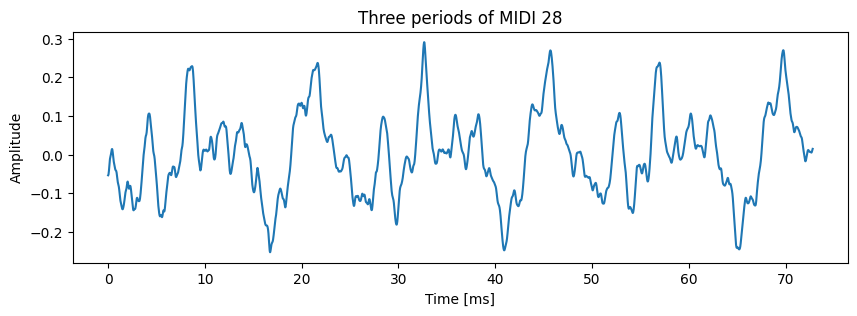

Spectrum of MIDI 28


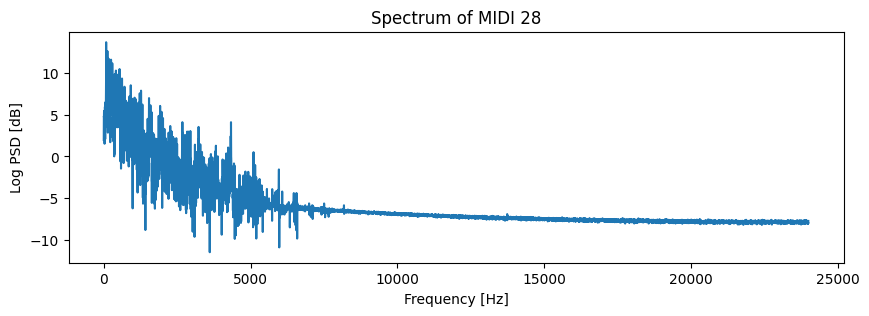

Three periods of MIDI 53


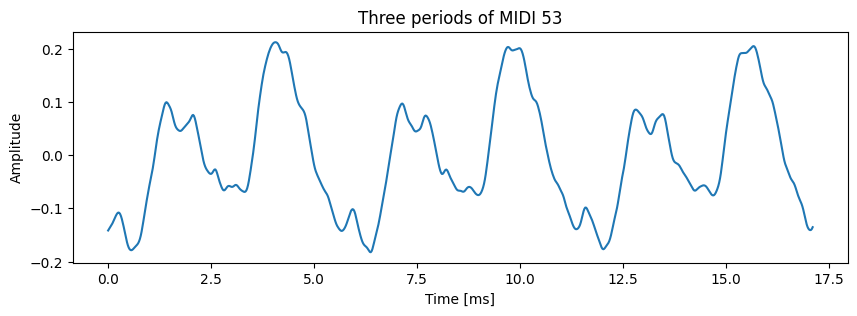

Spectrum of MIDI 53


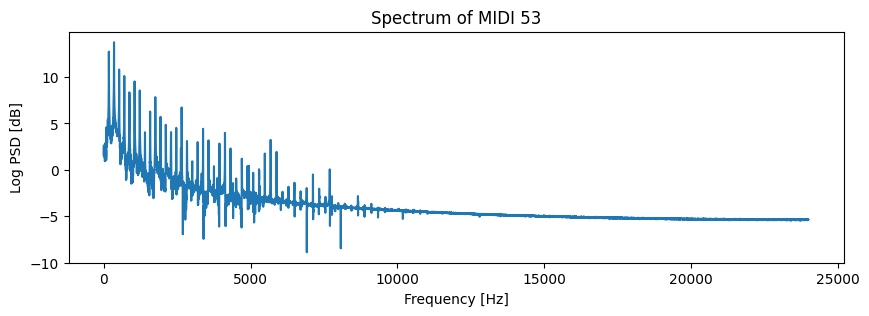

Three periods of MIDI 95


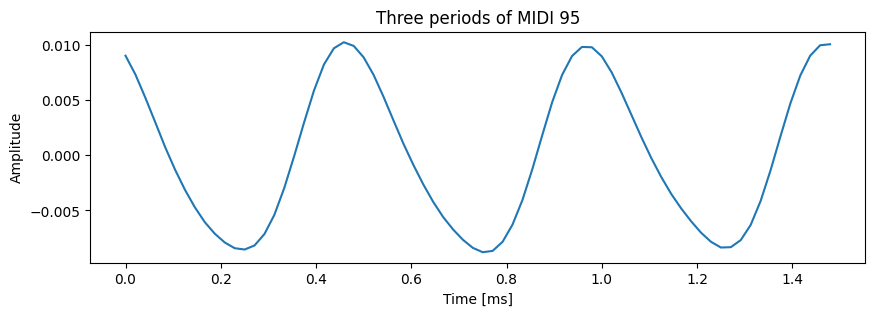

Spectrum of MIDI 95


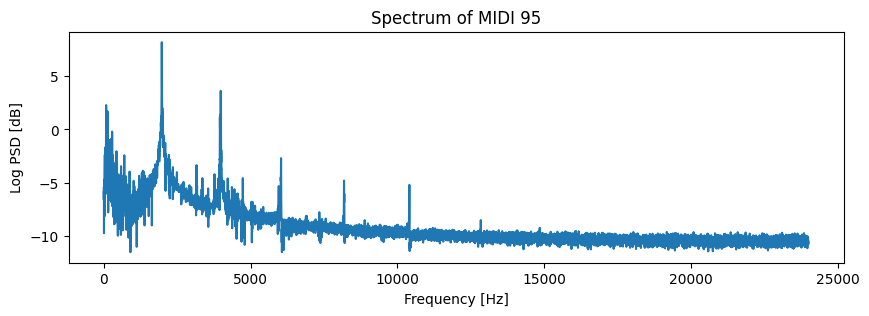

In [2]:
# Vykresleni 3 period prvniho tonu v ustalene casti.
print("Three periods of MIDI 28")
start1 = int((FIRST_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs))
end1 = int(start1 + (HOW_MUCH_SEC * Fs))
wave1 = s[start1 : end1]
period1 = wave1[ : 3 * t1]
time1 = np.arange(period1.size) / Fs * 1000
plt.figure(figsize = (10, 3))
plt.plot(time1, period1)
plt.title("Three periods of MIDI 28")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.show()

# Vypocet a vykresleni spektra celeho 0.5 s dlouheho useku prvniho tonu.
print("Spectrum of MIDI 28")
dft1 = np.abs(np.fft.fft(wave1))
dft_wave1 = dft1[ : dft1.size // 2]
freq1 = np.arange(dft_wave1.size) * (Fs / wave1.size)
plt.figure(figsize = (10, 3))
plt.plot(freq1, np.log(dft_wave1 ** 2 + (10 ** (-5))))
plt.title("Spectrum of MIDI 28")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

# Vykresleni 3 period druheho tonu v ustalene casti.
print("Three periods of MIDI 53")
start2 = int((SECOND_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs))
end2 = int(start2 + (HOW_MUCH_SEC * Fs))
wave2 = s[start2 : end2]
period2 = wave2[ : 3 * t2]
time2 = np.arange(period2.size) / Fs * 1000
plt.figure(figsize = (10, 3))
plt.plot(time2, period2)
plt.title("Three periods of MIDI 53")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.show()

# Vypocet a vykresleni spektra celeho 0.5 s dlouheho useku druheho tonu.
print("Spectrum of MIDI 53")
dft2 = np.abs(np.fft.fft(wave2))
dft_wave2 = dft2[ : dft2.size // 2]
freq2 = np.arange(dft_wave2.size) * (Fs / wave2.size)
plt.figure(figsize = (10, 3))
plt.plot(freq2, np.log(dft_wave2 ** 2 + (10 ** (-5))))
plt.title("Spectrum of MIDI 53")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

# Vykresleni 3 period tretiho tonu v ustalene casti.
print("Three periods of MIDI 95")
start3 = int((THIRD_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs))
end3 = int(start3 + (HOW_MUCH_SEC * Fs))
wave3 = s[start3 : end3]
period3 = wave3[ : 3 * t3]
time3 = np.arange(period3.size) / Fs * 1000
plt.figure(figsize = (10, 3))
plt.plot(time3, period3)
plt.title("Three periods of MIDI 95")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.show()

# Vypocet a vykresleni spektra celeho 0.5 s dlouheho useku tretiho tonu.
print("Spectrum of MIDI 95")
dft3 = np.abs(np.fft.fft(wave3))
dft_wave3 = dft3[ : dft3.size // 2]
freq3 = np.arange(dft_wave3.size) * (Fs / wave3.size)
plt.figure(figsize = (10, 3))
plt.plot(freq3, np.log(dft_wave3 ** 2 + (10 ** (-5))))
plt.title("Spectrum of MIDI 95")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

In [3]:
# Ulozeni zadanych tonu do jednotlivych souboru
print("Save three tones to files")
start_first = (FIRST_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs)
end_first = start_first + (HOW_MUCH_SEC * Fs)
start_second = (SECOND_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs)
end_second = start_second + (HOW_MUCH_SEC * Fs)
start_third = (THIRD_TONE - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs)
end_third = start_third + (HOW_MUCH_SEC * Fs)
sf.write('a_orig.wav', s[int(start_first) : int(end_first)], Fs)
sf.write('b_orig.wav', s[int(start_second) : int(end_second)], Fs)
sf.write('c_orig.wav', s[int(start_third) : int(end_third)], Fs)

Save three tones to files


### 2. Určení základní frekvence

K určení základní frekvence jsem použil obě doporučované metody, protože ani jedna z nich není schopna vypočítat požadovaně přesné výsledky pro všechny tóny. Pro tóny od MIDI 24 až MIDI 65 jsem použil metodu autokorelace, která dokáže vypočítat přesnější výsledky pro nižší frekvence, zatímco pro tóny od MIDI 66 až MIDI 108 byla přesnější metoda DFT.

Ačkoliv byly použity obě metody, odchylky od precizních základních frekvencí se i přesto vyskytly. Je to dáno tím, že použité metody nedokáží s maximální přesností určit základní frekvenci definovanou MIDI. Dalším problémem může být rozladění piana a to i přesto, že se jedná o vygenerovaný zvuk z počítačového programu. Do programu musí být nějakým způsobem nahrán skutečný zvuk ze skutečného piana, a proto je možné, že dané piano mohlo být nepatrně rozladěné.

Pro zadané tři tóny jsem následně zobrazil graf s použitou metodou, tj. pro tóny MIDI 28 a MIDI 53 autokorelaci, pro MIDI 95 metodu DFT. V grafech jsem následně vyznačil vypočítanou hodnotu (u autokorelace druhý nejvyšší vrchol grafu a u DFT maximální hodnotu grafu).

In [4]:
# Vypocet zakladni frekvence vsech tonu
# Pro tony od MIDI 24 az MIDI 65 pomoci autokorelace
# Pro tony od MIDI 66 az MIDI 108 pomoci DFT
print("Compute the fundamental frequency of all tones (Autocorrelation / DFT)")
fundamentals = np.zeros(MIDI_TO + 1)
peaks = np.zeros(MIDI_TO + 1)
for MIDI in range(MIDI_FROM, MIDI_TO + 1):
    start = int((MIDI - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs))
    end = int(start + (HOW_MUCH_SEC * Fs))
    wave = s[start : end]
    if MIDI < 66:
        autocorrelated = lb.autocorrelate(wave, max_size = Fs / 2)
        for index, value in enumerate(autocorrelated):
            if value < 0:
                min = index
                break
        peak = np.argmax(autocorrelated[min : ]) + min
        f0 = Fs / peak
    else:
        dft_wave = np.abs(np.fft.fft(wave))
        magnitude = dft_wave[ : len(dft_wave) // 2]
        f0 = np.argmax(magnitude) * (Fs / len(dft_wave))
    fundamentals[MIDI] = f0
    peaks[MIDI] = peak
    print(f"{MIDI} {np.round(f0, 2)}")

Compute the fundamental frequency of all tones (Autocorrelation / DFT)
24 32.81
25 34.76
26 36.84
27 39.02
28 41.34
29 43.8
30 46.42
31 49.18
32 52.12
33 55.17
34 58.47
35 61.94
36 65.57
37 69.46
38 73.62
39 77.92
40 82.62
41 87.75
42 92.84
43 98.36
44 104.35
45 110.6
46 117.07
47 123.71
48 131.15
49 138.73
50 147.24
51 155.84
52 164.95
53 175.18
54 185.33
55 196.72
56 207.79
57 220.18
58 234.15
59 247.42
60 262.3
61 277.46
62 294.48
63 311.69
64 328.77
65 350.36
66 370.0
67 392.0
68 416.0
69 440.0
70 466.0
71 494.0
72 524.0
73 554.0
74 588.0
75 622.0
76 660.0
77 698.0
78 740.0
79 784.0
80 830.0
81 882.0
82 932.0
83 988.0
84 1046.0
85 1108.0
86 1174.0
87 1244.0
88 1318.0
89 1396.0
90 1478.0
91 1566.0
92 1660.0
93 1758.0
94 1864.0
95 1976.0
96 2094.0
97 2218.0
98 2350.0
99 2490.0
100 2638.0
101 2796.0
102 2962.0
103 3138.0
104 3324.0
105 3522.0
106 3732.0
107 3954.0
108 4188.0


Plot the fundamental frequency of three tones


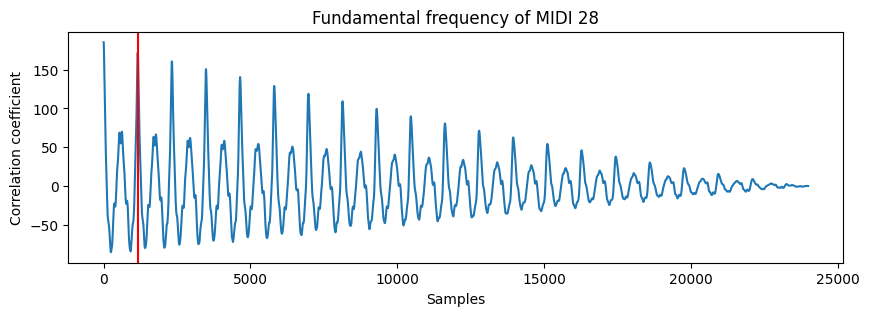

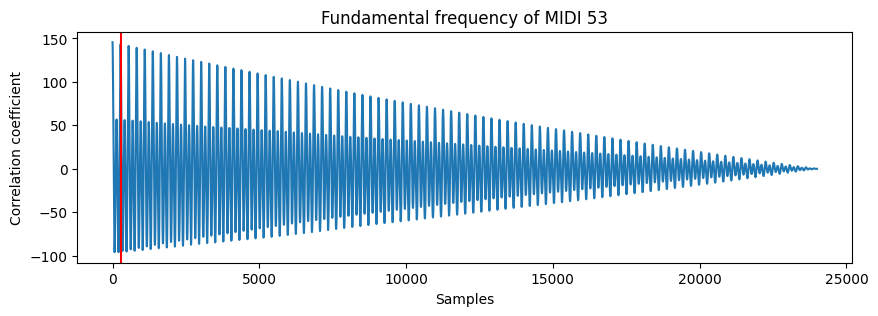

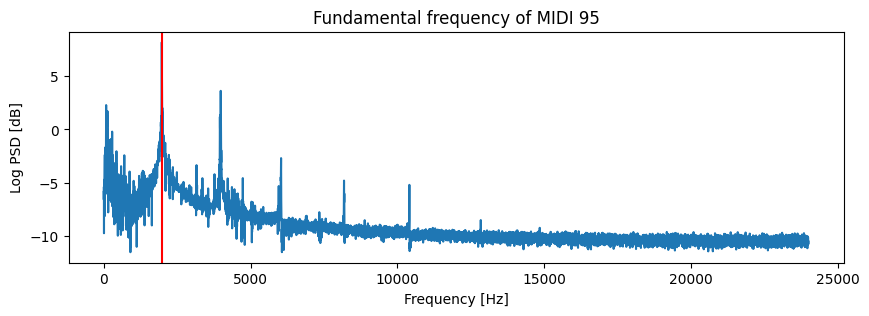

In [5]:
# Vykresleni zakladni frekvence tri tonu pomoci pouzite metody
print("Plot the fundamental frequency of three tones")
autocorrelated1 = lb.autocorrelate(wave1, max_size = Fs / 2)
plt.figure(figsize = (10, 3))
plt.plot(autocorrelated1)
plt.axvline(x = peaks[FIRST_TONE], color = 'red')
plt.title("Fundamental frequency of MIDI 28")
plt.xlabel("Samples")
plt.ylabel("Correlation coefficient")
plt.show()

autocorrelated2 = lb.autocorrelate(wave2, max_size = Fs / 2)
plt.figure(figsize = (10, 3))
plt.plot(autocorrelated2)
plt.axvline(x = peaks[SECOND_TONE], color = 'red')
plt.title("Fundamental frequency of MIDI 53")
plt.xlabel("Samples")
plt.ylabel("Correlation coefficient")
plt.show()

plt.figure(figsize = (10, 3))
plt.plot(freq3, np.log(dft_wave3 ** 2 + (10 ** (-5))))
plt.axvline(x = fundamentals[THIRD_TONE], color = 'red')
plt.title("Fundamental frequency of MIDI 95")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

### 3. Zpřesnění odhadu základní frekvence

Pro zpřesnění odhadu základní frekvence jsem použil postup, kdy jsem vypočítal koeficienty pro frekvence rozložené 100 centů okolo odhadnuté MIDI frekvence v předešlém úkolu. U některých frekvencí bylo zapotřebí výsledek podělit 2, protože implementovaná metoda DTFT našla až druhý koeficient.

Co se týče provnání, tak metoda DTFT vykázala značně přesnější výsledky oproti předešlým odhadnutým frekvencí pomocí autokorelace a DFT. I přesto se však u některých frekvencí stále odhadnutá frekvence mírně lišila od definované základní frekvence MIDI.

DTFT jsem implementoval takovým způsobem, že jsem pro každý tón vycházel z předešlého odhadu, kolem této odhadnuté frekvence jsem znovu spočítal DFT a následně vybral maximální hodnotu výsledku, což poté odpovídalo zpřesněnému odhadu základní frekvence. Můj kód byl silně inspirován kódem z přednášek (Python notebook).

In [6]:
# Zpresneni vypoctu zakladni frekvence vsech tonu pomoci DTFT
print("Compute the fundamental frequency of all tones (DTFT)")
dtft_fundamentals = np.zeros(MIDI_TO + 1)
n = np.arange(0, (Fs * HOW_MUCH_SEC))
i = np.arange(0, int((Fs * HOW_MUCH_SEC) / 2))
f = i / (Fs * HOW_MUCH_SEC) * Fs
for MIDI in range(MIDI_FROM, MIDI_TO + 1):
    start = int((MIDI - MIDI_FROM) * TONE_SAMPLES + (SKIP_SEC * Fs))
    end = int(start + (HOW_MUCH_SEC * Fs))
    wave = s[start : end]
    magnitude = np.abs(np.fft.fft(wave)[i])
    f0 = f[np.argmax(magnitude)]
    max = np.max(magnitude)
    dtft = np.linspace(f0 - INTERVAL, f0 + INTERVAL, STEP)
    A = np.zeros([STEP, int(Fs * HOW_MUCH_SEC)], dtype = complex)
    for k in np.arange(0, STEP):
        A[k, : ] = np.exp(-1j * 2 * np.pi * dtft[k] / Fs * n)
    dtft_wave = np.matmul(A, wave.T)
    if MIDI < 38 or (MIDI > 52 and MIDI < 56):
        dtft_f0 = dtft[np.argmax(np.abs(dtft_wave))] / 2
    elif MIDI > 37 and MIDI < 41:
        dtft_f0 = dtft[np.argmax(np.abs(dtft_wave))] / 3
    else:
        dtft_f0 = dtft[np.argmax(np.abs(dtft_wave))]
    dtft_fundamentals[MIDI] = dtft_f0
    print(f"{MIDI} {np.round(dtft_f0, 2)}")

Compute the fundamental frequency of all tones (DTFT)
24 32.62
25 34.62
26 36.62
27 38.87
28 41.13
29 43.62
30 46.13
31 48.87
32 51.87
33 54.87
34 58.13
35 61.62
36 65.38
37 69.13
38 73.42
39 77.75
40 82.42
41 87.75
42 92.75
43 98.25
44 104.25
45 110.75
46 117.25
47 123.25
48 130.75
49 138.25
50 146.75
51 155.25
52 164.75
53 174.87
54 185.13
55 196.13
56 207.75
57 220.25
58 233.25
59 247.25
60 261.75
61 277.25
62 293.75
63 311.25
64 329.75
65 349.25
66 369.75
67 391.75
68 415.25
69 440.25
70 466.25
71 493.75
72 523.25
73 554.25
74 587.25
75 622.25
76 659.25
77 697.75
78 739.25
79 783.25
80 829.75
81 879.24
82 931.25
83 987.75
84 1046.25
85 1108.25
86 1174.25
87 1244.25
88 1318.25
89 1395.75
90 1478.75
91 1566.75
92 1660.25
93 1758.75
94 1863.75
95 1976.25
96 2093.75
97 2218.75
98 2350.75
99 2490.25
100 2638.75
101 2795.25
102 2961.25
103 3137.25
104 3324.25
105 3521.75
106 3731.25
107 3953.25
108 4188.25


### 4. Reprezentace klavíru

V tomto úkolu jsem zobrazil spektrum všech tří zadaných tónů pro rozsah 0...11 * f0 (jako f0 jsem použil výsledek minulého úkolu - DTFT). Ve spektru jsem zobrazil 10 násobků základní frekvence. Na ose x jsou správné hodnoty, ale z nějakého důvodu se na ose y nezobrazovaly očekávané hodnoty, které by měly odpovídat vrcholům na grafu. Z tohoto bodu jsem se již nedokázal posunout vpřed, a proto jsem se k dalším úkolům již nedostal.

Plot the multiples of the fundamental frequency of MIDI 28


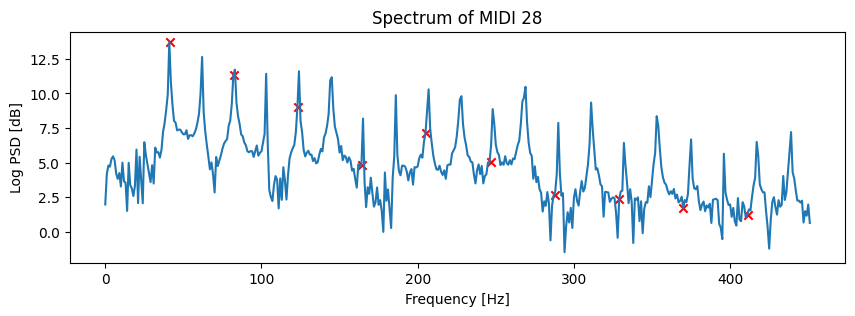

Plot the multiples of the fundamental frequency of MIDI 53


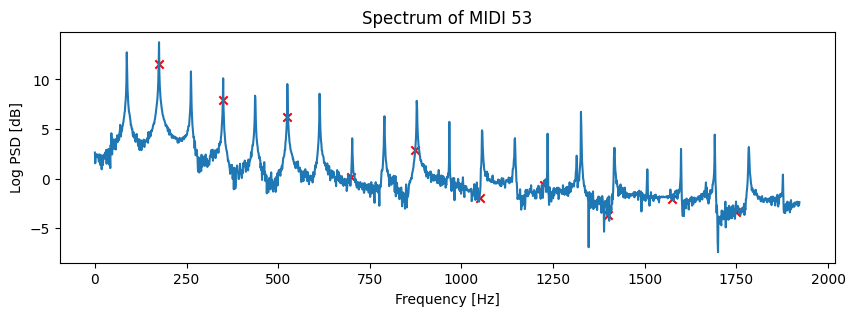

Plot the multiples of the fundamental frequency of MIDI 95


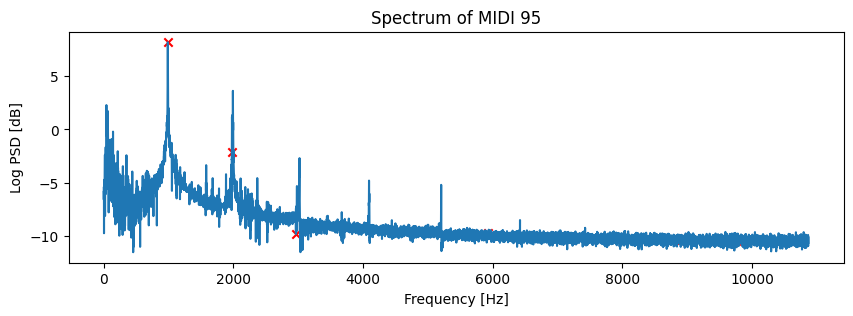

In [7]:
# Vykresleni nasobku zakladni frekvence prvniho tonu
print("Plot the multiples of the fundamental frequency of MIDI 28")
lim = dtft_fundamentals[28]
plt.figure(figsize = (10, 3))
plt.plot(np.log(dft_wave1 ** 2 + (10 ** (-5)))[ : int(11 * lim)])
plt.scatter(lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(lim)]), c = "red", marker = 'x')
plt.scatter(2 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(2 * lim)]), c = "red", marker = 'x')
plt.scatter(3 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(3 * lim)]), c = "red", marker = 'x')
plt.scatter(4 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(4 * lim)]), c = "red", marker = 'x')
plt.scatter(5 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(5 * lim)]), c = "red", marker = 'x')
plt.scatter(6 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(6 * lim)]), c = "red", marker = 'x')
plt.scatter(7 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(7 * lim)]), c = "red", marker = 'x')
plt.scatter(8 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(8 * lim)]), c = "red", marker = 'x')
plt.scatter(9 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(9 * lim)]), c = "red", marker = 'x')
plt.scatter(10 * lim, np.log((dft_wave1 ** 2 + (10 ** (-5)))[int(10 * lim)]), c = "red", marker = 'x')
plt.title("Spectrum of MIDI 28")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

# Vykresleni nasobku zakladni frekvence druheho tonu
print("Plot the multiples of the fundamental frequency of MIDI 53")
lim = dtft_fundamentals[53]
plt.figure(figsize = (10, 3))
plt.plot(np.log(dft_wave2 ** 2 + (10 ** (-5)))[ : int(11 * lim)])
plt.scatter(lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(lim)]), c = "red", marker = 'x')
plt.scatter(2 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(2 * lim)]), c = "red", marker = 'x')
plt.scatter(3 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(3 * lim)]), c = "red", marker = 'x')
plt.scatter(4 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(4 * lim)]), c = "red", marker = 'x')
plt.scatter(5 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(5 * lim)]), c = "red", marker = 'x')
plt.scatter(6 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(6 * lim)]), c = "red", marker = 'x')
plt.scatter(7 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(7 * lim)]), c = "red", marker = 'x')
plt.scatter(8 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(8 * lim)]), c = "red", marker = 'x')
plt.scatter(9 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(9 * lim)]), c = "red", marker = 'x')
plt.scatter(10 * lim, np.log((dft_wave2 ** 2 + (10 ** (-5)))[int(10 * lim)]), c = "red", marker = 'x')
plt.title("Spectrum of MIDI 53")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()

# Vykresleni nasobku zakladni frekvence tretiho tonu
print("Plot the multiples of the fundamental frequency of MIDI 95")
lim = dtft_fundamentals[95] / 2
plt.figure(figsize = (10, 3))
plt.plot(np.log(dft_wave3 ** 2 + (10 ** (-5)))[ : int(11 * lim)])
plt.scatter(lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(lim)]), c = "red", marker = 'x')
plt.scatter(2 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(2 * lim)]), c = "red", marker = 'x')
plt.scatter(3 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(3 * lim)]), c = "red", marker = 'x')
plt.scatter(4 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(4 * lim)]), c = "red", marker = 'x')
plt.scatter(5 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(5 * lim)]), c = "red", marker = 'x')
plt.scatter(6 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(6 * lim)]), c = "red", marker = 'x')
plt.scatter(7 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(7 * lim)]), c = "red", marker = 'x')
plt.scatter(8 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(8 * lim)]), c = "red", marker = 'x')
plt.scatter(9 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(9 * lim)]), c = "red", marker = 'x')
plt.scatter(10 * lim, np.log((dft_wave3 ** 2 + (10 ** (-5)))[int(10 * lim)]), c = "red", marker = 'x')
plt.title("Spectrum of MIDI 95")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Log PSD [dB]")
plt.show()